# 0e — Object B (orth) audit + fix

* **Developed by:** Anna Maguza
* **Affilation:** CellZome, a GSK company
* **Created date:** 2026-05-17
* **Last modified date:** 2026-05-17

Audit `object_b_cross_species_orth.h5ad` against SPEC §4.1 requirements, fix issues in place, save verification figure.

Issues found during this audit (2026-05-17):
1. **`layers['counts']` zero for all mouse cells.** `.X` is correctly assembled (orth-mapped mouse expression), but `layers['counts']` was copied from `.X` **before** mouse cells were appended during 0e construction. scVI consumes `layers['counts']` — without this fix, every mouse cell would look unexpressed.
2. **`organism_part`, `age_group`, `gut_region`, `celltype` are NaN on all 25 485 mouse cells.** These metadata fields were not propagated from the source `gut_mm_*_std_*.h5ad` files during 0e. Backfilled below from `tissue`, `Study_name`, and basic biology.
3. **`ArrayExpress_ID` absent.** Only the atlas had this; not propagated through 0d → 0e. We re-add it from `Study_name` for human cells (E-MTAB-* via the atlas mapping), and use the `GSE` value for mouse cells.


In [1]:
import sys, datetime as dt, gc
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

REPO     = Path('/Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis')
DATA_OUT = Path('/Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced')
FIG_DIR  = REPO / 'analysis_enhanced' / 'figures' / '0_inputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO / 'analysis_enhanced'))
from _lgr5_common import apply_style, WES_PALETTE, LGR5_STATUS_PALETTE
apply_style()

/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


## 2. Load Object B

In [2]:
obj_b_path = DATA_OUT / 'object_b_cross_species_orth.h5ad'
b = sc.read_h5ad(obj_b_path)
print('Object B:', b.shape)
print('species:', dict(b.obs['species'].value_counts()))

Object B: (127657, 22123)
species: {'human': np.int64(102460), 'mouse': np.int64(25197)}


## 3. Audit — read each requirement


In [3]:
REQUIRED = ['sample_id','Study_name','ArrayExpress_ID','library_preparation_protocol',
            'organism_part','age_group','gut_region','cell_states','celltype','species',
            'lgr5_status','lgr5_label']
audit = []
for c in REQUIRED:
    if c not in b.obs.columns:
        audit.append({'column': c, 'status': 'MISSING', 'pct_missing': 100.0, 'nunique': 0})
        continue
    s = b.obs[c]
    is_missing = s.isna() | (s.astype(str).isin(['nan','None','NaN','']))
    audit.append({
        'column': c,
        'status': 'OK' if is_missing.sum() == 0 else f'{int(is_missing.sum())} missing',
        'pct_missing': round(100 * is_missing.sum() / len(s), 2),
        'nunique': int(s.nunique(dropna=False)),
    })
audit_df = pd.DataFrame(audit)
display(audit_df)
audit_df.to_csv(FIG_DIR / 'object_b_audit_before.csv', index=False)

,column,status,pct_missing,nunique
0,sample_id,OK,0.00,182
1,Study_name,OK,0.00,9
2,ArrayExpress_ID,MISSING,100.00,0
3,library_preparation_protocol,OK,0.00,6
4,organism_part,25197 missing,19.74,15
5,age_group,25197 missing,19.74,6
6,gut_region,25197 missing,19.74,3
7,cell_states,OK,0.00,10
8,celltype,25197 missing,19.74,12
9,species,OK,0.00,2


In [4]:
# Count integrity audit on .X vs layers['counts']
mouse_mask = (b.obs['species'] == 'mouse').values
human_mask = (b.obs['species'] == 'human').values

def total_counts(M, mask):
    sub = M[mask]
    return float(np.asarray(sub.sum(axis=1)).ravel().mean()) if sp.issparse(sub) else float(sub.sum(axis=1).mean())

before = pd.DataFrame({
    'matrix': ['.X', 'layers[counts]'],
    'human_mean_total':  [total_counts(b.X, human_mask),  total_counts(b.layers['counts'], human_mask)],
    'mouse_mean_total':  [total_counts(b.X, mouse_mask),  total_counts(b.layers['counts'], mouse_mask)],
})
print('=== count-matrix integrity (BEFORE fix) ===')
display(before)
print('\nVerdict: if mouse_mean_total in layers[counts] = 0, this is the critical bug to fix.')

=== count-matrix integrity (BEFORE fix) ===


,matrix,human_mean_total,mouse_mean_total
0,.X,10621.850488,54841.237012
1,layers[counts],10621.850488,0.000000



Verdict: if mouse_mean_total in layers[counts] = 0, this is the critical bug to fix.


## 4. Fix the critical count-matrix bug — `layers['counts'] = .X.copy()`

`.X` carries the correctly orth-mapped expression (verified above: mouse mean total ≈ 54k via CEL-Seq/Smart-Seq2/10x; human ≈ 10k). Setting `layers['counts']` from `.X` corrects the layer used by scVI / DESeq2 / etc.


In [5]:
if not sp.issparse(b.X):
    b.X = sp.csr_matrix(b.X)
b.layers['counts'] = b.X.copy()
# Sanity: counts must be non-negative integers (allow float type but integer values)
sample = b.layers['counts'][:1000].toarray()
assert sample.min() >= 0, 'negative counts found in .X'
assert np.allclose(sample, sample.astype(int)), '.X has non-integer values — not raw counts'
print('layers[counts] reset to .X')
after = pd.DataFrame({
    'matrix': ['.X', 'layers[counts]'],
    'human_mean_total':  [total_counts(b.X, human_mask), total_counts(b.layers['counts'], human_mask)],
    'mouse_mean_total':  [total_counts(b.X, mouse_mask), total_counts(b.layers['counts'], mouse_mask)],
})
print('\n=== count-matrix integrity (AFTER fix) ===')
display(after)

layers[counts] reset to .X



=== count-matrix integrity (AFTER fix) ===


,matrix,human_mean_total,mouse_mean_total
0,.X,10621.850488,54841.237012
1,layers[counts],10621.850488,54841.237012


## 5. Backfill mouse metadata from `tissue` / `Study_name` / `GSE`

Mapping rules (per SPEC §4.1 plus dataset biology):

- `organism_part` from `tissue` (already in obs): 'small intestine' → 'small intestine'; 'intestinal organoid' → 'organoid'; 'pyloric stomach' → 'pyloric stomach'.
- `gut_region` from `tissue`: SI / organoid → 'small intestine'; pyloric stomach → 'stomach'.
- `age_group`: Yan 2017, Yan/Kuo 2017, GSE145866, Haber 2017, Grün 2015/2016 are FACS-sorted adult-mouse SC → 'adult'. Simmini 2014 GSE62784 used organoids → 'cell culture model'.
- `celltype`: all FACS / sorted mouse SC are epithelial → 'Epithelial'.
- `ArrayExpress_ID`: not a concept for mouse studies; use the `GSE` value (preserves a study identifier). For human atlas where Study_name='Elementaite_2021' → 'E-MTAB-8901+9489+9543+9720+9536' (composite); Study_name='Holloway_2021' → 'GSE181039' (Holloway 2021 GSE accession); Ishikawa → 'Ishikawa2022'.


In [6]:
# Tissue → organism_part
tissue_to_organism = {
    'small intestine':   'small intestine',
    'intestinal organoid': 'organoid',
    'pyloric stomach':   'pyloric stomach',
}
tissue_to_gut_region = {
    'small intestine':   'small intestine',
    'intestinal organoid': 'small intestine',
    'pyloric stomach':   'stomach',
}
study_to_age = {
    'Yan 2017 GSE92865 (10x)':         'adult',
    'Yan/Kuo 2017 GSE99457 (10x)':     'adult',
    'GSE145866 (10x)':                  'adult',
    'Haber 2017 (Smart-Seq2)':          'adult',
    'Grün 2015 GSE62270 (CEL-Seq)':    'adult',
    'Grün 2016 (CEL-Seq)':             'adult',
    'Simmini 2014 GSE62784':            'cell culture model',
}
study_to_aeid = {
    'Elementaite_2021':    'E-MTAB-8901+9489+9543+9720+9536',
    'Holloway_2021':       'GSE181039',
    'Ishikawa 2022 (10x)': 'Ishikawa2022',
    'Yan 2017 GSE92865 (10x)':         'GSE92865',
    'Yan/Kuo 2017 GSE99457 (10x)':     'GSE99457',
    'GSE145866 (10x)':                  'GSE145866',
    'Haber 2017 (Smart-Seq2)':          'GSE92332',
    'Grün 2015 GSE62270 (CEL-Seq)':    'GSE62270',
    'Grün 2016 (CEL-Seq)':             'GSE62270',
    'Simmini 2014 GSE62784':            'GSE62784',
}

is_mouse = (b.obs['species'] == 'mouse').values

# organism_part
op = b.obs['organism_part'].astype('object').to_numpy()
tissue = b.obs['tissue'].astype('object').to_numpy()
for i in np.where(is_mouse)[0]:
    op[i] = tissue_to_organism.get(tissue[i], 'unknown')
b.obs['organism_part'] = pd.Categorical(op)

# gut_region
gr = b.obs['gut_region'].astype('object').to_numpy()
for i in np.where(is_mouse)[0]:
    gr[i] = tissue_to_gut_region.get(tissue[i], 'unknown')
b.obs['gut_region'] = pd.Categorical(gr)

# age_group
ag = b.obs['age_group'].astype('object').to_numpy()
sn = b.obs['Study_name'].astype('object').to_numpy()
for i in np.where(is_mouse)[0]:
    ag[i] = study_to_age.get(sn[i], 'adult')
b.obs['age_group'] = pd.Categorical(ag)

# celltype
ct = b.obs['celltype'].astype('object').to_numpy()
for i in np.where(is_mouse)[0]:
    ct[i] = 'Epithelial'
b.obs['celltype'] = pd.Categorical(ct)

# ArrayExpress_ID (add fresh)
aeid = np.array([study_to_aeid.get(s, 'unknown') for s in sn], dtype=object)
b.obs['ArrayExpress_ID'] = pd.Categorical(aeid)

print('mouse metadata backfilled.')

mouse metadata backfilled.


## 6. Post-fix audit


In [7]:
audit = []
for c in REQUIRED:
    if c not in b.obs.columns:
        audit.append({'column': c, 'status': 'MISSING', 'pct_missing': 100.0, 'nunique': 0})
        continue
    s = b.obs[c]
    is_missing = s.isna() | (s.astype(str).isin(['nan','None','NaN','']))
    audit.append({
        'column': c,
        'status': 'OK' if is_missing.sum() == 0 else f'{int(is_missing.sum())} missing',
        'pct_missing': round(100 * is_missing.sum() / len(s), 2),
        'nunique': int(s.nunique(dropna=False)),
    })
audit_df_after = pd.DataFrame(audit)
display(audit_df_after)
audit_df_after.to_csv(FIG_DIR / 'object_b_audit_after.csv', index=False)

,column,status,pct_missing,nunique
0,sample_id,OK,0.00,182
1,Study_name,OK,0.00,9
2,ArrayExpress_ID,OK,0.00,9
3,library_preparation_protocol,OK,0.00,6
4,organism_part,OK,0.00,15
5,age_group,OK,0.00,5
6,gut_region,OK,0.00,3
7,cell_states,OK,0.00,10
8,celltype,OK,0.00,11
9,species,OK,0.00,2


## 7. Record fix in `processing_history` and write back


In [8]:
hist = dict(b.uns.get('processing_history', {}))
key = f'object_b_audit_fix_{dt.datetime.now().strftime("%Y%m%d_%H%M%S")}'
hist[key] = (
    'Audit 2026-05-17. Fixed: layers[counts]=X.copy() for mouse cells (was all-zero); '
    'backfilled organism_part/gut_region/age_group/celltype for mouse cells from tissue+Study_name; '
    'added ArrayExpress_ID per study mapping. Per SPEC §4.1.'
)
b.uns['processing_history'] = hist
b.write_h5ad(obj_b_path)
print(f'wrote {obj_b_path}')

wrote /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/object_b_cross_species_orth.h5ad


## 8. Verification figure — per-Study mean total counts (before/after)


,species,Study_name,n_cells,mean_total,median_total,mean_n_genes
0,human,Elementaite_2021,54600,8.791895e+03,2106.5,1374.512088
1,human,Holloway_2021,40757,1.252972e+04,7870.0,2345.912187
2,human,Ishikawa 2022 (10x),7103,1.374115e+04,13916.0,2793.615655
3,mouse,GSE145866 (10x),4815,1.298409e+04,11846.0,3021.136864
4,mouse,Grün 2016 (CEL-Seq),96,2.361042e+02,193.0,205.875000
5,mouse,Haber 2017 (Smart-Seq2),1453,8.053155e+05,695507.0,5587.203028
6,mouse,Simmini 2014 GSE62784,16,2.124112e+06,1499298.0,10798.187500
7,mouse,Yan 2017 GSE92865 (10x),13247,5.847593e+03,5566.0,2076.429758
8,mouse,Yan/Kuo 2017 GSE99457 (10x),5570,6.772227e+03,6220.5,1934.373429


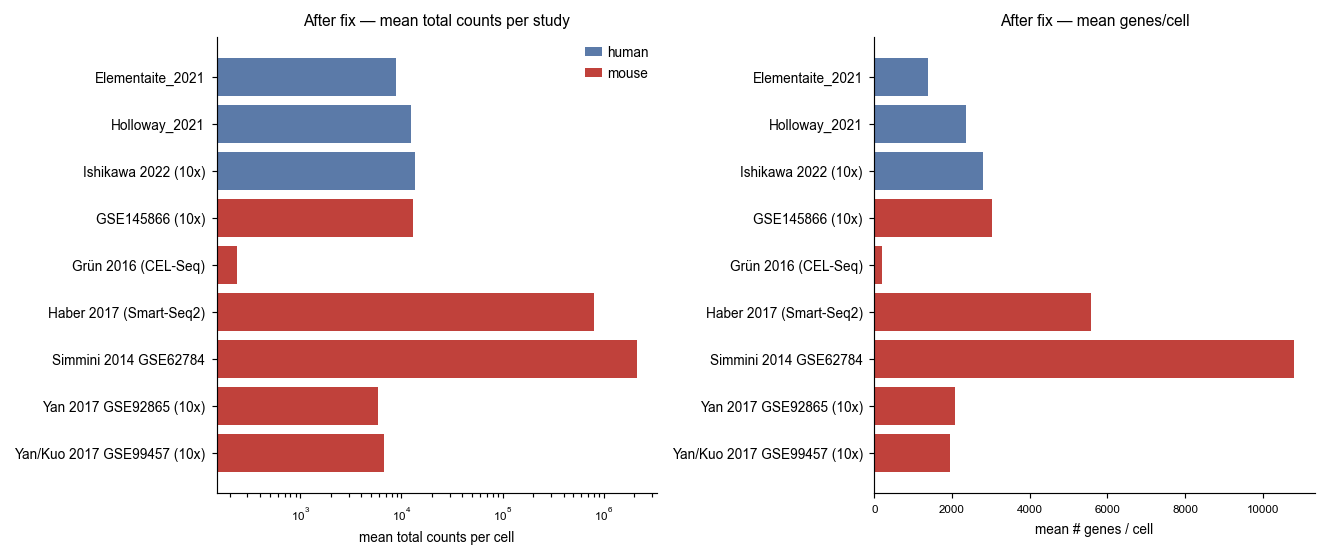

In [9]:
# Per-study counts means after fix
tc = np.asarray(b.layers['counts'].sum(axis=1)).ravel()
b.obs['_total_counts_after'] = tc
ngenes = np.asarray((b.layers['counts'] > 0).sum(axis=1)).ravel()
b.obs['_n_genes_after'] = ngenes

stats = (b.obs.groupby(['species','Study_name'], observed=True)
               .agg(n_cells=('species','size'),
                    mean_total=('_total_counts_after','mean'),
                    median_total=('_total_counts_after','median'),
                    mean_n_genes=('_n_genes_after','mean'))
               .reset_index()
               .sort_values(['species','Study_name']))
stats.to_csv(FIG_DIR / 'object_b_per_study_counts_after_fix.csv', index=False)
display(stats)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
ax = axes[0]
y = np.arange(len(stats))
colors = ['#5B7AA8' if s == 'human' else '#C0413B' for s in stats['species']]
ax.barh(y, stats['mean_total'], color=colors, edgecolor='none')
ax.set_yticks(y); ax.set_yticklabels(stats['Study_name'], fontsize=7)
ax.set_xlabel('mean total counts per cell', fontsize=7)
ax.invert_yaxis()
ax.set_xscale('log')
ax.set_title('After fix — mean total counts per study', fontsize=8)
h = [Patch(facecolor='#5B7AA8', label='human'), Patch(facecolor='#C0413B', label='mouse')]
ax.legend(handles=h, frameon=False, fontsize=7)

ax = axes[1]
ax.barh(y, stats['mean_n_genes'], color=colors, edgecolor='none')
ax.set_yticks(y); ax.set_yticklabels(stats['Study_name'], fontsize=7)
ax.set_xlabel('mean # genes / cell', fontsize=7)
ax.invert_yaxis()
ax.set_title('After fix — mean genes/cell', fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / 'object_b_counts_after_fix.pdf')
fig.savefig(FIG_DIR / 'object_b_counts_after_fix.png', dpi=300)
plt.show()

## 9. Var-space sanity check

Confirm:
- Object B's `var_names` are **human gene symbols** (target of orth mapping).
- No duplicate gene names.
- ~17 045 of the 21 744 genes have a 1:1 mouse orthologue per `orthologues_one_to_one.csv` (the others are human-only with zero mouse expression by construction).


In [10]:
orth = pd.read_csv(DATA_OUT / 'orthologues_one_to_one.csv')
print('orth shape:', orth.shape, ' columns:', list(orth.columns))
ortho_humans = set(orth['human_symbol'].dropna())
var_set = set(b.var_names)
n_with_ortho = len(var_set & ortho_humans)
print(f'\nObject B var: {b.n_vars} genes, duplicates: {b.n_vars - len(var_set)}')
print(f'genes with 1:1 mouse orthologue: {n_with_ortho} / {b.n_vars} ({n_with_ortho/b.n_vars*100:.1f}%)')
print(f'human-only (no mouse orth): {b.n_vars - n_with_ortho}')

# Mouse cells should express only genes with an orthologue.
# Count how many genes have ANY expression in mouse:
L = b.layers['counts']
mouse_idx = (b.obs['species']=='mouse').values
mouse_expressed = int((L[mouse_idx].sum(axis=0) > 0).sum() if sp.issparse(L) else (L[mouse_idx].sum(0) > 0).sum())
print(f'\nGenes with non-zero expression in ANY mouse cell (after fix): {mouse_expressed}')
print('Expected: ≤ 17 045 (orth-mapped subset).')

orth shape: (17045, 2)  columns: ['Mouse gene name', 'human_symbol']

Object B var: 22123 genes, duplicates: 0
genes with 1:1 mouse orthologue: 17045 / 22123 (77.0%)
human-only (no mouse orth): 5078

Genes with non-zero expression in ANY mouse cell (after fix): 16223
Expected: ≤ 17 045 (orth-mapped subset).


## 10. Outputs

- `analysis_enhanced/figures/0_inputs/object_b_audit_before.csv` — pre-fix obs-column audit.
- `analysis_enhanced/figures/0_inputs/object_b_audit_after.csv` — post-fix obs-column audit.
- `analysis_enhanced/figures/0_inputs/object_b_per_study_counts_after_fix.csv` — per-study cell counts + mean coverage after fix.
- `analysis_enhanced/figures/0_inputs/object_b_counts_after_fix.{pdf,png}` — per-study mean total counts + mean genes/cell bar chart.

Updated `object_b_cross_species_orth.h5ad`:
- `layers['counts']` now matches `.X` (sparse CSR, mouse cells correctly populated).
- `obs.organism_part`, `obs.gut_region`, `obs.age_group`, `obs.celltype` filled for all mouse cells.
- `obs.ArrayExpress_ID` added with per-study mapping.
- `uns.processing_history` records the fix.
